In [1]:
import pandas as pd                                    # data tables
import numpy as np                                     # math operations
import matplotlib.pyplot as plt                        # charts
from sklearn.model_selection import train_test_split   # split data
from sklearn.preprocessing import StandardScaler       # normalization
from sklearn.linear_model import LinearRegression      # model 1
from sklearn.ensemble import RandomForestRegressor     # model 2
from xgboost import XGBRegressor                       # model 3
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # metrics
from sklearn.metrics import confusion_matrix, roc_curve, auc                   # classification metrics

These libraries were imported to support data preprocessing, model training, and evaluation. Pandas handles data manipulation, NumPy performs numerical operations, Matplotlib creates visualizations, Scikit-learn provides preprocessing and model tools, and XGBoost provides gradient boosting regression.

In [2]:
df = pd.read_csv('LengthOfStay.csv')   # read CSV into table
df.head()                               # show first 5 rows

,eid,vdate,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,...,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,discharged,facid,lengthofstay
0,1,8/29/2012,0,F,0,0,0,0,0,0,...,192.476918,12.0,1.390722,30.432418,96,6.5,4,9/1/2012,B,3
1,2,5/26/2012,5+,F,0,0,0,0,0,0,...,94.078507,8.0,0.943164,28.460516,61,6.5,1,6/2/2012,A,7
2,3,9/22/2012,1,F,0,0,0,0,0,0,...,130.530524,12.0,1.065750,28.843812,64,6.5,2,9/25/2012,B,3
3,4,8/9/2012,0,F,0,0,0,0,0,0,...,163.377028,12.0,0.906862,27.959007,76,6.5,1,8/10/2012,A,1
4,5,12/20/2012,0,F,0,0,0,1,0,1,...,94.886654,11.5,1.242854,30.258927,67,5.6,2,12/24/2012,E,4


In [3]:
print("Shape:", df.shape)               # rows and columns count
print("Columns:", df.columns.tolist())  # all column names

Shape: (100000, 28)
Columns: ['eid', 'vdate', 'rcount', 'gender', 'dialysisrenalendstage', 'asthma', 'irondef', 'pneum', 'substancedependence', 'psychologicaldisordermajor', 'depress', 'psychother', 'fibrosisandother', 'malnutrition', 'hemo', 'hematocrit', 'neutrophils', 'sodium', 'glucose', 'bloodureanitro', 'creatinine', 'bmi', 'pulse', 'respiration', 'secondarydiagnosisnonicd9', 'discharged', 'facid', 'lengthofstay']


In [4]:
df.isnull().sum()   # count missing values per column
# confirms no missing values before analysis

,0
eid,0
vdate,0
rcount,0
gender,0
dialysisrenalendstage,0
asthma,0
irondef,0
pneum,0
substancedependence,0
psychologicaldisordermajor,0


In [5]:
df['vdate']      = pd.to_datetime(df['vdate'])          # convert to date
df['discharged'] = pd.to_datetime(df['discharged'])      # convert to date
df['calculatedlos'] = (df['discharged'] - df['vdate']).dt.days  # manual LOS
print((df['lengthofstay'] - df['calculatedlos']).value_counts())
# all zeros = target variable is accurate

0    100000
Name: count, dtype: int64


I recalculated the length of stay using admission and discharge dates to verify that the provided target variable is correct. All 100,000 records show a difference of zero, confirming the lengthofstay column is accurate and trustworthy for modeling.

In [6]:
df = df.drop(columns=[
    'eid',                         # patient ID — not a predictor
    'vdate',                       # admission date — already used
    'discharged',                  # discharge date — already used
    'calculatedlos',               # created just for verification
    'gender',                      # not clinically significant for LOS prediction
    'secondarydiagnosisnonicd9'    # represents coding info, not actual condition
])
print("Shape:", df.shape)          # (100000, 23)

Shape: (100000, 23)


In [7]:
df['rcount'] = df['rcount'].replace('5+', '5').astype(int)  # fix text to number
print("Unique rcount values:", df['rcount'].unique())         # verify fix

Unique rcount values: [0 5 1 3 4 2]


rcount had text values like "5+", which cannot be used for calculations. So, "5+" was changed to 5 to make it a number. Higher rcount means the patient had more previous admissions and may be related to longer hospital stays.

In [8]:
df = pd.get_dummies(df, columns=['facid'], drop_first=False)  # one-hot encode A-E
for col in ['facid_A', 'facid_B', 'facid_C', 'facid_D', 'facid_E']:
    df[col] = df[col].astype(int)    # convert True/False to 1/0
print("Shape after encoding:", df.shape)  # (100000, 27)

Shape after encoding: (100000, 27)


In [9]:
df.isnull().sum()   # confirm no nulls created during encoding

,0
rcount,0
dialysisrenalendstage,0
asthma,0
irondef,0
pneum,0
substancedependence,0
psychologicaldisordermajor,0
depress,0
psychother,0
fibrosisandother,0



Represents hospitals A, B, C, D, E. No natural ordering exists between hospitals so one-hot encoding was applied. This creates 5 separate binary columns and prevents incorrect assumptions about ordinal relationships.

In [10]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns.drop('lengthofstay')
corr = df[numeric_cols.tolist() + ['lengthofstay']].corr()   # pearson correlation
print(corr['lengthofstay'].sort_values(ascending=False).round(4))  # sorted by strength

lengthofstay                  1.0000
rcount                        0.7495
facid_E                       0.3265
psychologicaldisordermajor    0.2867
hemo                          0.2177
irondef                       0.1938
psychother                    0.1917
malnutrition                  0.1744
dialysisrenalendstage         0.1697
bloodureanitro                0.1483
substancedependence           0.1479
pneum                         0.1355
depress                       0.1214
facid_C                       0.0837
asthma                        0.0820
facid_D                       0.0760
fibrosisandother              0.0621
pulse                         0.0067
bmi                           0.0001
glucose                      -0.0034
sodium                       -0.0035
creatinine                   -0.0040
neutrophils                  -0.0107
respiration                  -0.0223
hematocrit                   -0.0640
facid_B                      -0.1989
facid_A                      -0.2028
N

## Correlation Analysis

Pearson correlation was used to measure the linear relationship between each feature and length of stay (LOS).

The results show that **rcount** has the strongest positive correlation, indicating that patients with more readmissions tend to stay longer.

Facility-related variables and some medical conditions show moderate correlation with LOS.

Several features show very low correlation. However, these features were NOT removed because correlation captures only linear relationships.

Medical data often contains non-linear patterns, which can be effectively learned by models such as Random Forest and XGBoost.

Therefore, correlation was used only for understanding the data and not for feature selection.

## Phase I — All Features
3 models were trained using all available features after preprocessing.

In [11]:
X = df.drop('lengthofstay', axis=1)   # all features
y = df['lengthofstay']                 # target variable

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)   # 80% train, 20% test
X_train = X_train.copy()   # avoid SettingWithCopyWarning
X_test  = X_test.copy()

print("Train:", X_train.shape)   # (80000, 26)
print("Test :", X_test.shape)    # (20000, 26)

Train: (80000, 26)
Test : (20000, 26)


In [12]:
X_train = X_train.drop(columns=['facid_A'])   # dummy variable trap
X_test  = X_test.drop(columns=['facid_A'])    # drop from both

scaler = StandardScaler()                      # normalization tool
cols = X_train.columns.tolist()                # all feature names
X_train[cols] = scaler.fit_transform(X_train[cols])   # fit + scale train
X_test[cols]  = scaler.transform(X_test[cols])        # scale test only

print("X_train:", X_train.shape)   # (80000, 25)
print("X_test :", X_test.shape)    # (20000, 25)

X_train: (80000, 25)
X_test : (20000, 25)


Split done BEFORE scaling to prevent data leakage.

##Performance Metrics

R² (R-Squared): Measures how much of the variation in length of stay (LOS) is explained by the model. For example, R² = 0.96 means the model explains 96% of the variation in patient stay duration. Higher is better.

MAE (Mean Absolute Error): Measures the average prediction error in days. For example, MAE = 0.36 means predictions are off by about 0.36 days on average. Lower is better.

RMSE (Root Mean Squared Error): Similar to MAE but penalizes larger errors more heavily. RMSE = 0.48 indicates that large prediction errors are minimized. Lower is better.

##Model Justification

**Linear Regression** — Baseline model. Assumes straight-line relationship. Simple and interpretable. Shows how much improvement complex models add.

**Random Forest** — 100 independent trees averaged. Handles non-linear relationships and feature interactions. Binary conditions (0/1) are perfect for tree splits.

**XGBoost** — Trees built sequentially, each correcting the previous one's errors. Best generalisation. Industry standard for structured tabular medical data.

In [13]:
lr = LinearRegression()            # create model
lr.fit(X_train, y_train)           # train on training data
lr_tr = lr.predict(X_train)        # predict on train
lr_te = lr.predict(X_test)         # predict on test

print("LINEAR REGRESSION — PHASE I")
print("Train R2  :", round(r2_score(y_train,lr_tr),2), "| Test R2  :", round(r2_score(y_test,lr_te),2))
print("Train MAE :", round(mean_absolute_error(y_train,lr_tr),2), "| Test MAE :", round(mean_absolute_error(y_test,lr_te),2))
print("Train RMSE:", round(np.sqrt(mean_squared_error(y_train,lr_tr)),2), "| Test RMSE:", round(np.sqrt(mean_squared_error(y_test,lr_te)),2))

LINEAR REGRESSION — PHASE I
Train R2  : 0.76 | Test R2  : 0.77
Train MAE : 0.88 | Test MAE : 0.87
Train RMSE: 1.16 | Test RMSE: 1.14


In [14]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)   # 100 trees
rf.fit(X_train, y_train)           # train
rf_tr = rf.predict(X_train)        # predict train
rf_te = rf.predict(X_test)         # predict test

print("RANDOM FOREST — PHASE I")
print("Train R2  :", round(r2_score(y_train,rf_tr),2), "| Test R2  :", round(r2_score(y_test,rf_te),2))
print("Train MAE :", round(mean_absolute_error(y_train,rf_tr),2), "| Test MAE :", round(mean_absolute_error(y_test,rf_te),2))
print("Train RMSE:", round(np.sqrt(mean_squared_error(y_train,rf_tr)),2), "| Test RMSE:", round(np.sqrt(mean_squared_error(y_test,rf_te)),2))

RANDOM FOREST — PHASE I
Train R2  : 0.99 | Test R2  : 0.93
Train MAE : 0.15 | Test MAE : 0.39
Train RMSE: 0.24 | Test RMSE: 0.64


In [15]:
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)  # 100 sequential trees
xgb.fit(X_train, y_train)           # train
xgb_tr = xgb.predict(X_train)      # predict train
xgb_te = xgb.predict(X_test)       # predict test

print("XGBOOST — PHASE I")
print("Train R2  :", round(r2_score(y_train,xgb_tr),2), "| Test R2  :", round(r2_score(y_test,xgb_te),2))
print("Train MAE :", round(mean_absolute_error(y_train,xgb_tr),2), "| Test MAE :", round(mean_absolute_error(y_test,xgb_te),2))
print("Train RMSE:", round(np.sqrt(mean_squared_error(y_train,xgb_tr)),2), "| Test RMSE:", round(np.sqrt(mean_squared_error(y_test,xgb_te)),2))

XGBOOST — PHASE I
Train R2  : 0.97 | Test R2  : 0.96
Train MAE : 0.34 | Test MAE : 0.36
Train RMSE: 0.44 | Test RMSE: 0.48


In [16]:
train_comp = pd.DataFrame({
    'Model'     : ['Linear Regression', 'Random Forest', 'XGBoost'],
    'Train R2'  : [round(r2_score(y_train,lr_tr),2), round(r2_score(y_train,rf_tr),2), round(r2_score(y_train,xgb_tr),2)],
    'Train MAE' : [round(mean_absolute_error(y_train,lr_tr),2), round(mean_absolute_error(y_train,rf_tr),2), round(mean_absolute_error(y_train,xgb_tr),2)],
    'Train RMSE': [round(np.sqrt(mean_squared_error(y_train,lr_tr)),2), round(np.sqrt(mean_squared_error(y_train,rf_tr)),2), round(np.sqrt(mean_squared_error(y_train,xgb_tr)),2)]
})
print("PHASE I — TRAINING COMPARISON")
print(train_comp.to_string(index=False))   # side by side table

PHASE I — TRAINING COMPARISON
            Model  Train R2  Train MAE  Train RMSE
Linear Regression      0.76       0.88        1.16
    Random Forest      0.99       0.15        0.24
          XGBoost      0.97       0.34        0.44


In [17]:
test_comp = pd.DataFrame({
    'Model'    : ['Linear Regression', 'Random Forest', 'XGBoost'],
    'Test R2'  : [round(r2_score(y_test,lr_te),2), round(r2_score(y_test,rf_te),2), round(r2_score(y_test,xgb_te),2)],
    'Test MAE' : [round(mean_absolute_error(y_test,lr_te),2), round(mean_absolute_error(y_test,rf_te),2), round(mean_absolute_error(y_test,xgb_te),2)],
    'Test RMSE': [round(np.sqrt(mean_squared_error(y_test,lr_te)),2), round(np.sqrt(mean_squared_error(y_test,rf_te)),2), round(np.sqrt(mean_squared_error(y_test,xgb_te)),2)]
})
print("PHASE I — TESTING COMPARISON")
print(test_comp.to_string(index=False))   # side by side table

PHASE I — TESTING COMPARISON
            Model  Test R2  Test MAE  Test RMSE
Linear Regression     0.77      0.87       1.14
    Random Forest     0.93      0.39       0.64
          XGBoost     0.96      0.36       0.48


##Phase I — Best Model: XGBoost

XGBoost is the best-performing model in Phase I.

It achieves the highest test R² (0.96), meaning it explains 96% of the variation in length of stay (LOS).

It also has the lowest error values (MAE = 0.36, RMSE = 0.48), indicating highly accurate predictions.

Compared to Linear Regression, XGBoost performs better because LOS does not follow a simple linear relationship.

Compared to Random Forest, XGBoost shows better generalisation, as it maintains high accuracy on both training and testing data without overfitting.

## Classification Evaluation — Phase I

To evaluate classification performance, the regression output was converted into a binary classification problem.

A threshold of 4 days (median LOS) was used:
0 = short stay  
1 = long stay  

This allows evaluation using confusion matrix and AUC.

In [18]:
# PHASE I — CONFUSION MATRIX FOR EACH MODEL
y_test_class = (y_test > 4).astype(int)
print("Threshold: 4 days (median LOS)\n")

for name, pred in [("LINEAR REGRESSION", lr_te),
                   ("RANDOM FOREST", rf_te),
                   ("XGBOOST", xgb_te)]:
    pred_class = (pred > 4).astype(int)
    cm = confusion_matrix(y_test_class, pred_class)
    acc = round((cm[0][0]+cm[1][1])/cm.sum(), 4)
    print(f"CONFUSION MATRIX — {name}")
    print(f"  True Negative  (correct short) : {cm[0][0]}")
    print(f"  False Positive (wrong long)    : {cm[0][1]}")
    print(f"  False Negative (wrong short)   : {cm[1][0]}")
    print(f"  True Positive  (correct long)  : {cm[1][1]}")
    print(f"  Accuracy: {acc}\n")

Threshold: 4 days (median LOS)

CONFUSION MATRIX — LINEAR REGRESSION
  True Negative  (correct short) : 10458
  False Positive (wrong long)    : 1909
  False Negative (wrong short)   : 1046
  True Positive  (correct long)  : 6587
  Accuracy: 0.8522

CONFUSION MATRIX — RANDOM FOREST
  True Negative  (correct short) : 10577
  False Positive (wrong long)    : 1790
  False Negative (wrong short)   : 188
  True Positive  (correct long)  : 7445
  Accuracy: 0.9011

CONFUSION MATRIX — XGBOOST
  True Negative  (correct short) : 10942
  False Positive (wrong long)    : 1425
  False Negative (wrong short)   : 73
  True Positive  (correct long)  : 7560
  Accuracy: 0.9251



XGBoost is the best model because it has the highest accuracy (92.5%) and the lowest number of critical errors, especially false negatives (only 73). This means it correctly identifies most patients and rarely makes dangerous mistakes like predicting a short stay when the patient actually needs a long stay, making it the most reliable model for hospital decision-making.

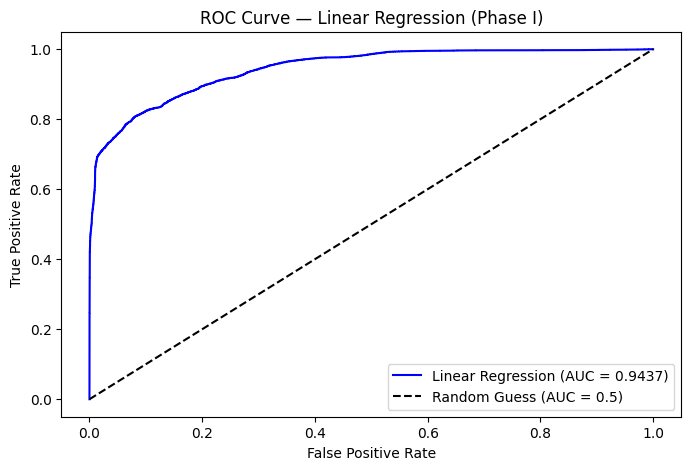

Linear Regression AUC: 0.9437



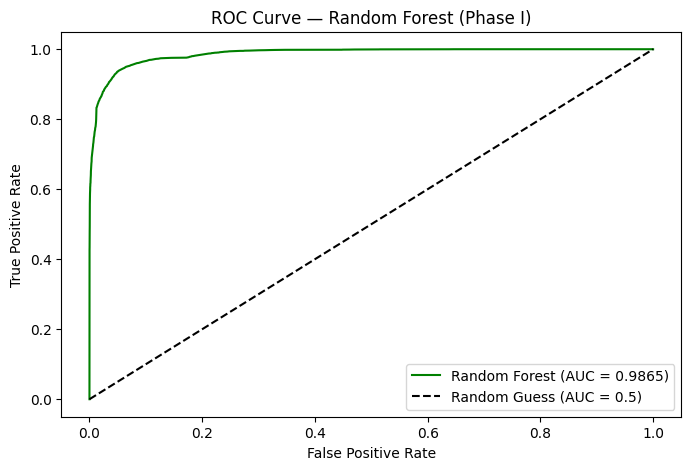

Random Forest AUC: 0.9865



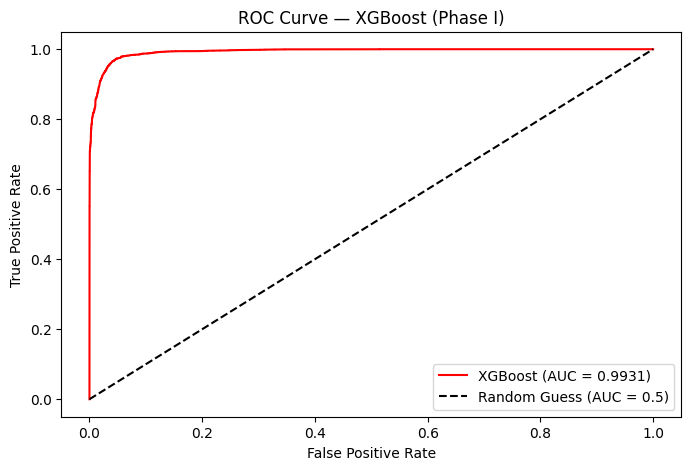

XGBoost AUC: 0.9931



In [19]:
# ROC Curve for each model (separate charts)
for name, pred, color in [("Linear Regression", lr_te, "blue"),
                          ("Random Forest", rf_te, "green"),
                          ("XGBoost", xgb_te, "red")]:

    fpr, tpr, _ = roc_curve(y_test_class, pred)   # compute ROC points
    roc_auc = auc(fpr, tpr)                       # calculate AUC score

    plt.figure(figsize=(8, 5))
    plt.plot(fpr, tpr, color=color,
             label=f'{name} (AUC = {roc_auc:.4f})')   # plot ROC curve
    plt.plot([0, 1], [0, 1], 'k--',
             label='Random Guess (AUC = 0.5)')   # baseline reference

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve — {name} (Phase I)')
    plt.legend()
    plt.show()
    print(f"{name} AUC: {round(roc_auc, 4)}\n")   # print performance

All three models are performing well because their ROC curves are above the diagonal line, which means they are better than random guessing. XGBoost is the best model because it has the highest AUC (0.9931), which means it can almost perfectly separate short and long stay patients. Random Forest also performs very well, and Linear Regression performs slightly lower but still good. So overall, XGBoost is the best model.

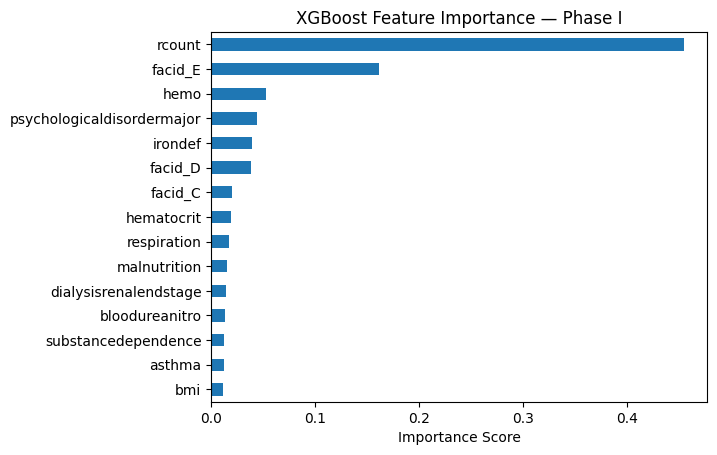

rcount                        0.454027
facid_E                       0.160995
hemo                          0.053118
psychologicaldisordermajor    0.043521
irondef                       0.039161
facid_D                       0.038653
facid_C                       0.020368
hematocrit                    0.019020
respiration                   0.017056
malnutrition                  0.015368
dialysisrenalendstage         0.014202
bloodureanitro                0.013034
substancedependence           0.012599
asthma                        0.012405
bmi                           0.011729
glucose                       0.011350
creatinine                    0.010824
sodium                        0.010708
pulse                         0.010489
pneum                         0.009907
neutrophils                   0.007589
depress                       0.005051
psychother                    0.004918
fibrosisandother              0.002256
facid_B                       0.001651
dtype: float32


In [20]:
importance = xgb.feature_importances_                    # importance scores
feat_imp = pd.Series(importance, index=X_train.columns)  # map to feature names
feat_imp = feat_imp.sort_values()                         # sort low to high
feat_imp.tail(15).plot(kind='barh')                       # horizontal bar chart

plt.title("XGBoost Feature Importance — Phase I")
plt.xlabel("Importance Score")
plt.show()

print(feat_imp.sort_values(ascending=False))              # print all scores

## Feature Importance — Phase I

The XGBoost feature importance results show that **rcount** is the most important feature in predicting length of stay (LOS). This indicates that the number of readmissions within the last 180 days has the strongest impact on how long a patient stays in the hospital. Patients with more frequent readmissions tend to require longer care.

The next important feature is **facid_E**, suggesting that the hospital facility also plays a role in determining LOS.

Medical conditions such as **hemo**, **iron deficiency**, **psychological disorders**, and **renal end-stage disease** have a moderate impact on LOS.

Other conditions like **depression**, **fibrosis**, **malnutrition**, and **pneumonia** show low importance, meaning they contribute less to the model’s prediction.

## Phase II — Health Conditions Only

Repeat all Phase I steps using only the 11 health condition columns.

Goal: Identify which medical conditions are associated with longer hospital stays and explain why.

In [21]:
condition_cols = [
    'dialysisrenalendstage',       # kidney dialysis
    'asthma',                      # breathing condition
    'irondef',                     # iron deficiency
    'pneum',                       # pneumonia
    'substancedependence',         # substance abuse
    'psychologicaldisordermajor',  # major psychological disorder
    'depress',                     # depression
    'psychother',                  # psychotherapy related
    'fibrosisandother',            # fibrosis
    'malnutrition',                # malnutrition
    'hemo'                         # blood disorder
]
# 11 binary columns — 0 = no condition, 1 = has condition
print("Condition columns:", condition_cols)

Condition columns: ['dialysisrenalendstage', 'asthma', 'irondef', 'pneum', 'substancedependence', 'psychologicaldisordermajor', 'depress', 'psychother', 'fibrosisandother', 'malnutrition', 'hemo']


In [22]:
X2 = df[condition_cols]               # only condition features
y2 = df['lengthofstay']              # same target

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42)   # same split ratio
X2_train = X2_train.copy()
X2_test  = X2_test.copy()

scaler2 = StandardScaler()                                        # new scaler for phase II
X2_train[condition_cols] = scaler2.fit_transform(X2_train[condition_cols])  # fit + scale
X2_test[condition_cols]  = scaler2.transform(X2_test[condition_cols])      # scale only

print("Train:", X2_train.shape)   # (80000, 11)
print("Test :", X2_test.shape)    # (20000, 11)

Train: (80000, 11)
Test : (20000, 11)


In [23]:
lr2 = LinearRegression()            # create model
lr2.fit(X2_train, y2_train)         # train
lr2_tr = lr2.predict(X2_train)      # predict train
lr2_te = lr2.predict(X2_test)       # predict test

print("LINEAR REGRESSION — PHASE II")
print("Train R2  :", round(r2_score(y2_train,lr2_tr),2), "| Test R2  :", round(r2_score(y2_test,lr2_te),2))
print("Train MAE :", round(mean_absolute_error(y2_train,lr2_tr),2), "| Test MAE :", round(mean_absolute_error(y2_test,lr2_te),2))
print("Train RMSE:", round(np.sqrt(mean_squared_error(y2_train,lr2_tr)),2), "| Test RMSE:", round(np.sqrt(mean_squared_error(y2_test,lr2_te)),2))

LINEAR REGRESSION — PHASE II
Train R2  : 0.18 | Test R2  : 0.18
Train MAE : 1.77 | Test MAE : 1.76
Train RMSE: 2.14 | Test RMSE: 2.12


In [24]:
rf2 = RandomForestRegressor(n_estimators=100, random_state=42)   # 100 trees
rf2.fit(X2_train, y2_train)          # train
rf2_tr = rf2.predict(X2_train)       # predict train
rf2_te = rf2.predict(X2_test)        # predict test

print("RANDOM FOREST — PHASE II")
print("Train R2  :", round(r2_score(y2_train,rf2_tr),2), "| Test R2  :", round(r2_score(y2_test,rf2_te),2))
print("Train MAE :", round(mean_absolute_error(y2_train,rf2_tr),2), "| Test MAE :", round(mean_absolute_error(y2_test,rf2_te),2))
print("Train RMSE:", round(np.sqrt(mean_squared_error(y2_train,rf2_tr)),2), "| Test RMSE:", round(np.sqrt(mean_squared_error(y2_test,rf2_te)),2))

RANDOM FOREST — PHASE II
Train R2  : 0.22 | Test R2  : 0.21
Train MAE : 1.72 | Test MAE : 1.71
Train RMSE: 2.09 | Test RMSE: 2.08


In [25]:
xgb2 = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)  # 100 trees
xgb2.fit(X2_train, y2_train)         # train
xgb2_tr = xgb2.predict(X2_train)    # predict train
xgb2_te = xgb2.predict(X2_test)     # predict test

print("XGBOOST — PHASE II")
print("Train R2  :", round(r2_score(y2_train,xgb2_tr),2), "| Test R2  :", round(r2_score(y2_test,xgb2_te),2))
print("Train MAE :", round(mean_absolute_error(y2_train,xgb2_tr),2), "| Test MAE :", round(mean_absolute_error(y2_test,xgb2_te),2))
print("Train RMSE:", round(np.sqrt(mean_squared_error(y2_train,xgb2_tr)),2), "| Test RMSE:", round(np.sqrt(mean_squared_error(y2_test,xgb2_te)),2))

XGBOOST — PHASE II
Train R2  : 0.22 | Test R2  : 0.21
Train MAE : 1.72 | Test MAE : 1.71
Train RMSE: 2.09 | Test RMSE: 2.08


In [26]:
train_comp2 = pd.DataFrame({
    'Model'     : ['Linear Regression', 'Random Forest', 'XGBoost'],
    'Train R2'  : [round(r2_score(y2_train,lr2_tr),2), round(r2_score(y2_train,rf2_tr),2), round(r2_score(y2_train,xgb2_tr),2)],
    'Train MAE' : [round(mean_absolute_error(y2_train,lr2_tr),2), round(mean_absolute_error(y2_train,rf2_tr),2), round(mean_absolute_error(y2_train,xgb2_tr),2)],
    'Train RMSE': [round(np.sqrt(mean_squared_error(y2_train,lr2_tr)),2), round(np.sqrt(mean_squared_error(y2_train,rf2_tr)),2), round(np.sqrt(mean_squared_error(y2_train,xgb2_tr)),2)]
})
print("PHASE II — TRAINING COMPARISON")
print(train_comp2.to_string(index=False))   # side by side table

PHASE II — TRAINING COMPARISON
            Model  Train R2  Train MAE  Train RMSE
Linear Regression      0.18       1.77        2.14
    Random Forest      0.22       1.72        2.09
          XGBoost      0.22       1.72        2.09


In [27]:
test_comp2 = pd.DataFrame({
    'Model'    : ['Linear Regression', 'Random Forest', 'XGBoost'],
    'Test R2'  : [round(r2_score(y2_test,lr2_te),2), round(r2_score(y2_test,rf2_te),2), round(r2_score(y2_test,xgb2_te),2)],
    'Test MAE' : [round(mean_absolute_error(y2_test,lr2_te),2), round(mean_absolute_error(y2_test,rf2_te),2), round(mean_absolute_error(y2_test,xgb2_te),2)],
    'Test RMSE': [round(np.sqrt(mean_squared_error(y2_test,lr2_te)),2), round(np.sqrt(mean_squared_error(y2_test,rf2_te)),2), round(np.sqrt(mean_squared_error(y2_test,xgb2_te)),2)]
})
print("PHASE II — TESTING COMPARISON")
print(test_comp2.to_string(index=False))   # side by side table

PHASE II — TESTING COMPARISON
            Model  Test R2  Test MAE  Test RMSE
Linear Regression     0.18      1.76       2.12
    Random Forest     0.21      1.71       2.08
          XGBoost     0.21      1.71       2.08


Phase II — Best Model: XGBoost

Test R² = 0.21 | Test MAE = 1.71 | Test RMSE = 2.08

XGBoost is selected as the best model in Phase II because it provides the highest testing performance (R² = 0.21) with the lowest error values.

Although Random Forest gives similar results, XGBoost is preferred because it shows consistent performance and better generalisation.

The results clearly show that health conditions alone explain only a small portion of the variation in length of stay.

This indicates that other factors such as readmissions (rcount), lab values, and facility type play a much larger role in determining hospital stay duration.

## Classification Evaluation — Phase II

To evaluate classification performance, LOS was converted into a binary variable using a threshold of 4 days.

0 = short stay  
1 = long stay  

This allows comparison of model performance using confusion matrix and AUC.

In [28]:
# PHASE II — CONFUSION MATRIX FOR EACH MODEL
y2_test_class = (y2_test > 4).astype(int)
print("Threshold: 4 days (median LOS)\n")

for name, pred in [("LINEAR REGRESSION", lr2_te),
                   ("RANDOM FOREST", rf2_te),
                   ("XGBOOST", xgb2_te)]:
    pred_class = (pred > 4).astype(int)
    cm = confusion_matrix(y2_test_class, pred_class)
    acc = round((cm[0][0]+cm[1][1])/cm.sum(), 4)
    print(f"CONFUSION MATRIX — {name}")
    print(f"  True Negative  (correct short) : {cm[0][0]}")
    print(f"  False Positive (wrong long)    : {cm[0][1]}")
    print(f"  False Negative (wrong short)   : {cm[1][0]}")
    print(f"  True Positive  (correct long)  : {cm[1][1]}")
    print(f"  Accuracy: {acc}\n")

Threshold: 4 days (median LOS)

CONFUSION MATRIX — LINEAR REGRESSION
  True Negative  (correct short) : 8714
  False Positive (wrong long)    : 3653
  False Negative (wrong short)   : 3104
  True Positive  (correct long)  : 4529
  Accuracy: 0.6622

CONFUSION MATRIX — RANDOM FOREST
  True Negative  (correct short) : 8553
  False Positive (wrong long)    : 3814
  False Negative (wrong short)   : 2926
  True Positive  (correct long)  : 4707
  Accuracy: 0.663

CONFUSION MATRIX — XGBOOST
  True Negative  (correct short) : 8547
  False Positive (wrong long)    : 3820
  False Negative (wrong short)   : 2919
  True Positive  (correct long)  : 4714
  Accuracy: 0.663



In Phase II, all models perform poorly. The accuracy is only around 66%, and there are many wrong predictions. Both false positives and false negatives are high, which means the models are making a lot of mistakes. All three models show almost the same performance, so no model is clearly better. This happens because only medical condition features are used, and they are not enough to correctly classify short and long stay patients.

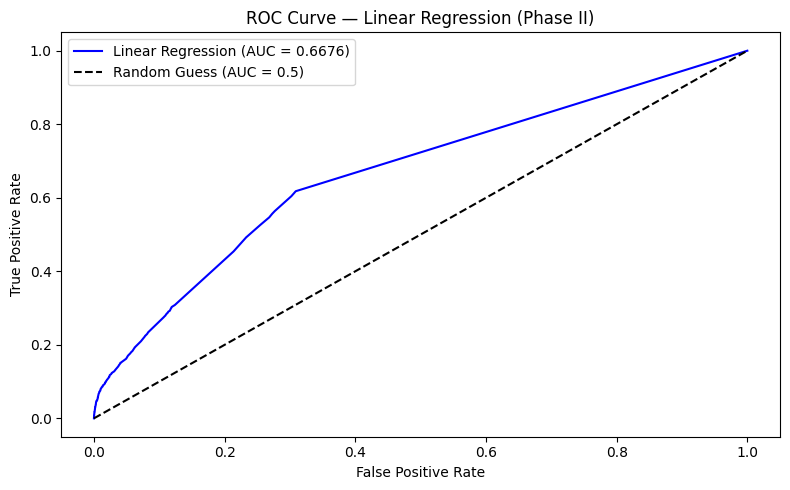

Linear Regression AUC: 0.6676



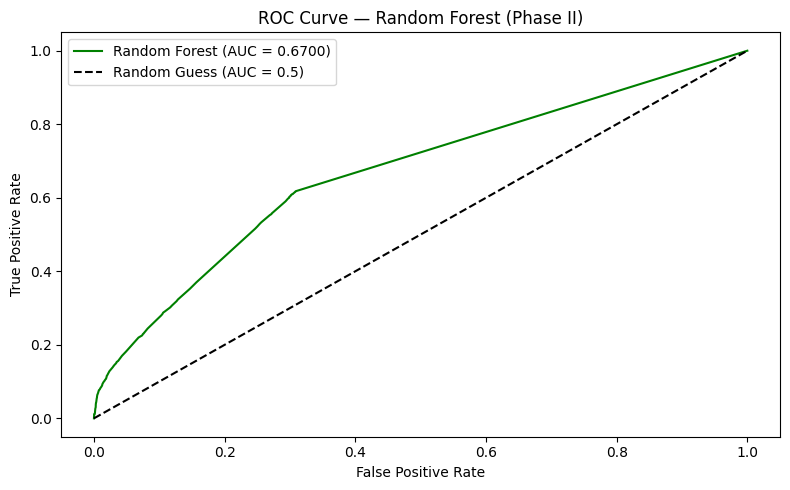

Random Forest AUC: 0.67



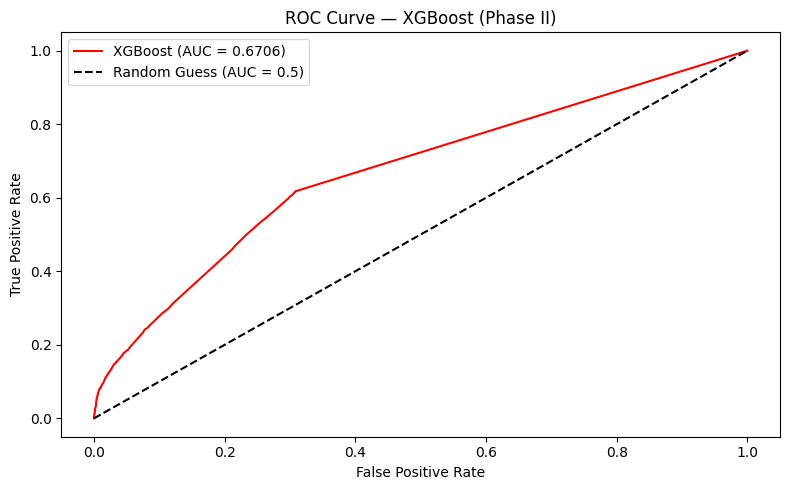

XGBoost AUC: 0.6706



In [29]:
# PHASE II — AUC-ROC FOR EACH MODEL (separate charts)
for name, pred, color in [("Linear Regression", lr2_te, "blue"),
                          ("Random Forest", rf2_te, "green"),
                          ("XGBoost", xgb2_te, "red")]:
    fpr, tpr, _ = roc_curve(y2_test_class, pred)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8, 5))
    plt.plot(fpr, tpr, color=color, label=f'{name} (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5)')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve — {name} (Phase II)')
    plt.legend()
    plt.tight_layout()
    plt.show()
    print(f"{name} AUC: {round(roc_auc, 4)}\n")

In Phase II, all three models have AUC values around 0.67, which is only slightly better than random guessing. The ROC curves are close to the diagonal line, which means the models are not able to clearly distinguish between short and long stay patients. All models perform almost the same, so none of them is clearly better. This shows that using only medical condition features is not enough for accurate prediction

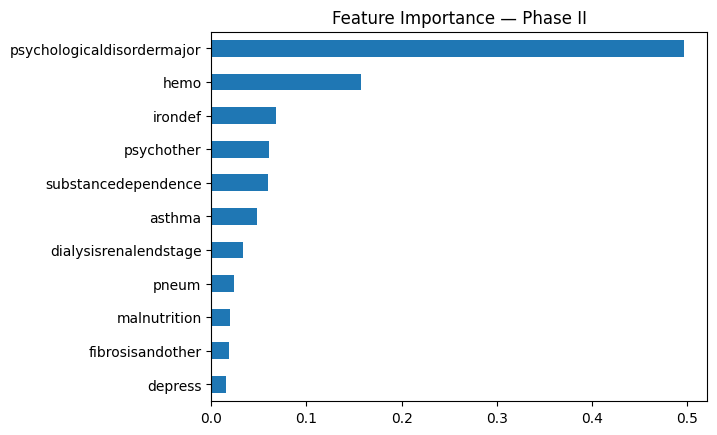

psychologicaldisordermajor    0.496151
hemo                          0.157032
irondef                       0.068198
psychother                    0.060973
substancedependence           0.059702
asthma                        0.047767
dialysisrenalendstage         0.032893
pneum                         0.024027
malnutrition                  0.019976
fibrosisandother              0.018223
depress                       0.015058
dtype: float32


In [30]:
feat_imp2 = pd.Series(xgb2.feature_importances_, index=condition_cols)  # importance scores
feat_imp2.sort_values().plot(kind='barh')   # horizontal bar chart

plt.title("Feature Importance — Phase II")
plt.show()

print(feat_imp2.sort_values(ascending=False))   # print all scores

## Feature Importance — Phase II

The feature importance results show that **psychologicaldisordermajor** is the most important condition affecting length of stay. Patients with major psychological disorders tend to stay longer due to the need for continuous monitoring and treatment.

The next important condition is **hemo (blood-related conditions)**, which also increases hospital stay because it requires ongoing care and management.

Conditions like **iron deficiency**, **psychotherapy**, and **substance dependence** have moderate impact on length of stay.

Other conditions such as **asthma**, **renal end-stage disease**, and **pneumonia** have lower impact.

Conditions like **malnutrition**, **fibrosis**, and **depression** have the least influence on length of stay.

Overall, the results show that certain serious conditions, especially psychological disorders and blood-related issues, are more likely to result in longer hospital stays compared to other conditions.